In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
import matplotlib.patches as mpatches


input_path  = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\samples day1-10.xlsx"
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\all_real_samples_combined.xlsx"



# Reading without headers, just to find the header row
df_raw = pd.read_excel(input_path, header=None)

# getting the data columns
header_row = df_raw[df_raw.iloc[:,0].astype(str).str.strip() == "Peak"].index[0]

# Re-reading using that row as the header
potato_data = pd.read_excel(input_path, header=header_row)

# Dropping any completely empty columns
data = potato_data.dropna(axis=1, how="all")

#  Seeing the dataframe
print(data.shape)
print(data.columns.tolist())
print(data.head())

(633, 175)
['Peak', 'tR1', 'tR2', 'tR', 'm/z', 'ID Names', 's1 S96_44_B1_D1_T1', 's1 S96_44_B1_D1_T2', 's3 S96_9_B1_D1_T1', 's4 S96_28_B1_D1_T1', 's5 S96_92_B1_D1_T1', 's6 S96_21_B1_D1_T1', 's7 S96_53_B1_D1_T1', 's8 S96_55_B1_D1_T1', 's9 S96_44_B1_D1_T2', 's10 S96_55_B1_D1_T2', 's11 S96_21_B1_D1_T2', 's12 S96_14_B1_D1_T2', 's13 S96_7_B1_D1_T2', 's14 S96_83_B1_D1_T2', 's15 S96_92_B1_D1_T2', 's16 S96_28_B1_D1_T2', 's17 S96_83_B1_D1_T1', 's18 S96_7_B1_D1_T1', 's19 S96_53_B1_D1_T2', 's20 S96_42_B1_D2_T1', 's21 S96_56_B1_D2_T1', 's22 S96_6_B1_D2_T1', 's23 S96_38_B1_D2_T1', 's24 S96_48_B1_D2_T1', 's25 S96_76_B1_D2_T1', 's26 S96_10_B1_D2_T1', 's27 S96_38_B1_D2_T2', 's28 S96_76_B1_D2_T2', 's29 S96_48_B1_D2_T2', 's30 S96_6_B1_D2_T2', 's31 S96_10_B1_D2_T2', 's32 S96_42_B1_D2_T2', 's33 S96_79_B1_D2_T2', 's34 S96_86_B1_D2_T2', 's35 S96_56_B1_D2_T2', 's36 S96_79_B1_D2_T1', 's37 S96_86_B1_D2_T1', 's38 S96_87_B1_D3_T1', 's39 S96_16_B1_D3_T1', 's40 S96_81_B1_D3_T1', 's41 S96_81_B1_D3_T2', 's42 S96_50_

 AS can be seen the dataframe includes 633 rows  and 175 columns including peak id , retention time , Id names and samples name with their peak intensity

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Columns: 175 entries, Peak to s169 S96_39_B1_D3_T1
dtypes: float64(3), int64(171), object(1)
memory usage: 865.6+ KB


# Data preparation

In [3]:
# keep only the first 100 columns: 5 RT/meta + 1 ID + 94 samples
selected_data = data.iloc[:, :101]


# Getting missing values

In [4]:
selected_data.isnull().sum()

Peak                   0
tR1                    0
tR2                    0
tR                     0
m/z                    0
                      ..
s91 S96_12_B1_D5_T2    0
s92 S96_93_B1_D5_T2    0
s93 S96_15_B1_D6_T1    0
s94 S96_59_B1_D6_T1    0
s95 S96_25_B1_D6_T1    0
Length: 101, dtype: int64


tR is already essentially the arithmetic mean of tR1 and tR2 (differences on the order of 10⁻⁴ minutes).



In [5]:

# the pairwise differences to find the realation between retention times
diff_t_vs_1 = (selected_data['tR'] - selected_data['tR1']).abs()
diff_t_vs_2 = (selected_data['tR'] - selected_data['tR2']).abs()
diff_1_vs_2 = (selected_data['tR1'] - selected_data['tR2']).abs()
avg_t   = (selected_data['tR1'] + selected_data['tR2']) / 2
diff_avg_vs_t = (avg_t - selected_data['tR']).abs()

# printing to see the results
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    633.000000
mean       0.050104
std        0.035097
min        0.015000
25%        0.028000
50%        0.041000
75%        0.061000
max        0.369000
dtype: float64 

abs(tR - tR2):
 count    633.000000
mean       0.050137
std        0.035105
min        0.015000
25%        0.027000
50%        0.041000
75%        0.061000
max        0.369000
dtype: float64 

abs(tR1 - tR2):
 count    633.000000
mean       0.100242
std        0.070199
min        0.030000
25%        0.055000
50%        0.081000
75%        0.122000
max        0.738000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    6.330000e+02
mean     2.330174e-04
std      2.496198e-04
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      5.000000e-04
max      5.000000e-04
dtype: float64 




the two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.


In [6]:


# Use tR_best instead of three tr
selected_data['tR_best'] = (selected_data['tR1'] + selected_data['tR2']) / 2

# Drop unnecessary columns
to_keep = [col for col in selected_data.columns if col not in ['tR1', 'tR2', 'tR']]
cleaned_sample_data = selected_data[to_keep]


# Confirm that 'tR_best' is included
print("tR_best column saved:", 'tR_best' in cleaned_sample_data.columns)

cols = cleaned_sample_data.columns.tolist()

# Move 'tR_best' after 'Peak'
cols.insert(cols.index('Peak') + 1, cols.pop(cols.index('tR_best')))

# Reorder the DataFrame
cleaned_sample_data = cleaned_sample_data[cols]

#  The result
print(cleaned_sample_data.head())
# Save cleaned data with tR_best
cleaned_sample_data.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_sample_data.csv", index=False)


tR_best column saved: True
   Peak  tR_best  m/z                                           ID Names  \
0     1   1.9055   40    0.14%  || 40                                ...   
1     2   1.9625   44    1.40%  || 44   69  119                      ...   
2     3   1.9745   81    0.19%  || 81   96  169                      ...   
3     4   1.9955   42   12.80%  || 42  64  48  40  38  37  66  50  36...   
4     5   2.0415   41   10.30%  || 41  39  47  56  77  65  49  60    ...   

   s1 S96_44_B1_D1_T1  s1 S96_44_B1_D1_T2  s3 S96_9_B1_D1_T1  \
0               10596               20120              16056   
1               65017               61775              59978   
2               25722               21276              24105   
3             3396147             2999719            1910915   
4             3040149             3299916            1060080   

   s4 S96_28_B1_D1_T1  s5 S96_92_B1_D1_T1  s6 S96_21_B1_D1_T1  ...  \
0               19568               14816               21952

In the metrix_qc_preparation notebook, I prepared the qc data and after getting the stable qc4 , peak 70 was the most stable so we use this peak for normalization of sample data

# Using peak70 of qc data for normalization of sample data

In [7]:

import pandas as pd

# Load the QC data (renamed variable)
qc_tidy = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_qc.csv"
)

# Filter for Peak 70 only (still using qc_tidy as base)
peak70_df = qc_tidy[qc_tidy['Peak'] == 70]

# Display the result
print(peak70_df)



    Peak  tR_best  m/z                                           ID Names  \
69    70   5.3015   85   33.80%  || 85  114   86   44   58   67   83  ...   

    s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  \
69              5630187              9978615             12721979   

    s4 S96_QC4_B1_D1_T1  s5 S96_QC1_B1_D2_T1  s6 S96_QC2_B1_D2_T1  ...  \
69             13912365              5934613             10139703  ...   

    s31 S96_QC3_B1_D7_T1  s32 S96_QC4_B1_D10_T1  s33 S96_QC4_B1_D6_T1  \
69              12557932               13940573              13940573   

    s34 S96_QC4_B1_D7_T1  s35 S96_QC2_B1_D8_T1  s36 S96_QC3_B1_D8_T1  \
69              13940573               6434328               9979507   

    s37 S96_QC4_B1_D8_T1  s38 S96_QC2_B1_D10_T1  s39 S96_QC2_B1_D6_T1  \
69              12164678               10006498              10006498   

    s40 S96_QC2_B1_D7_T1  
69              10006498  

[1 rows x 44 columns]


In [8]:
# build normalization dictionary
peak70_series = peak70_df.iloc[0]
peak70_intensities = peak70_series.filter(like="QC4").to_dict()

# Normalize the Tidy Sample Data

In [10]:

# Extract Peak 70 from cleaned QC and get QC4 columns only 
peak70_qc = qc_tidy[qc_tidy['Peak'] == 70]

# Define metadata columns to exclude
metadata_cols = ['Peak', 'm/z', 'ID Names', 'tR_best']

# Identify QC4 columns 
qc4_cols = [col for col in peak70_qc.columns if 'QC4' in col and col not in metadata_cols]

# Calculate the average Peak 70 intensity from QC4 
qc4_peak70_mean = peak70_qc[qc4_cols].mean(axis=1).values[0]
print(f"Average Peak 70 intensity (QC4): {qc4_peak70_mean}")

# Make a tidy sample data from cleaned_sample_data 
tidy_sample_data = cleaned_sample_data.melt(
    id_vars=['Peak', 'tR_best', 'm/z', 'ID Names'],
    var_name='Sample',
    value_name='Intensity'
).dropna(subset=['Intensity'])

# Save tidy raw sample data 
tidy_sample_data.to_csv("tidy_raw_sample_data.csv", index=False)

#Copy raw tidy data for future reference
raw_tidy_sample_data = tidy_sample_data.copy()

# Normalize by average QC4 Peak 70 intensity
tidy_sample_data['Peak70_Intensity'] = qc4_peak70_mean
tidy_sample_data['Normalized_Intensity'] = tidy_sample_data['Intensity'] / qc4_peak70_mean

#  Save normalized tidy sample data
tidy_sample_data.to_csv("normalized_tidy_sample_data.csv", index=False)
print(" Normalized tidy sample data saved as 'normalized_tidy_sample_data.csv'")


Average Peak 70 intensity (QC4): 13493404.3
 Normalized tidy sample data saved as 'normalized_tidy_sample_data.csv'


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_14672\1127966198.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
C:\Users\fatemehm\AppData\Local\Temp\ipykernel_14672\1127966198.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


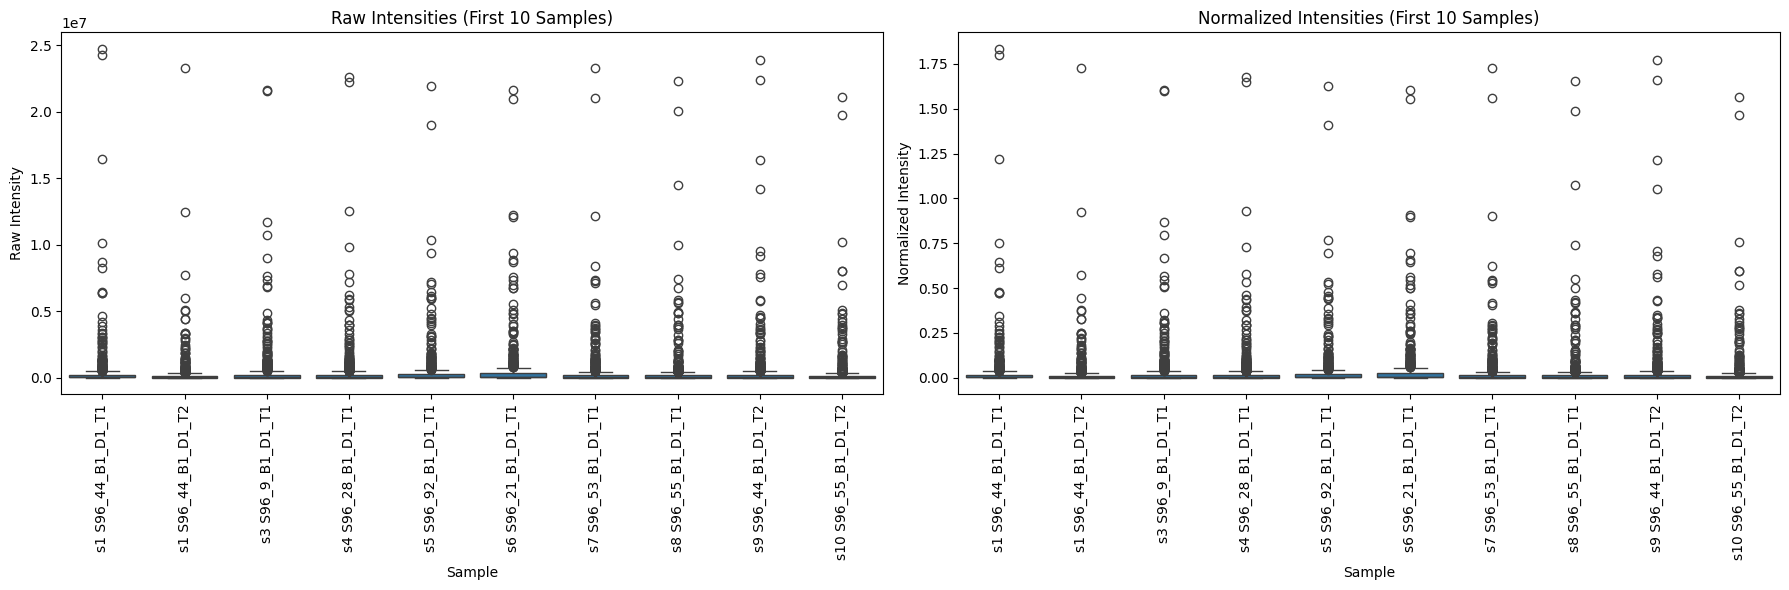

In [11]:


# Load tidy raw and normalized data
raw_df = pd.read_csv("tidy_raw_sample_data.csv")
norm_df = pd.read_csv("normalized_tidy_sample_data.csv")

# --- Choose a consistent subset of samples ---
first_10_samples = raw_df['Sample'].unique()[:10]

# Subset both datasets
raw_subset = raw_df[raw_df['Sample'].isin(first_10_samples)].copy()
norm_subset = norm_df[norm_df['Sample'].isin(first_10_samples)].copy()

# --- Plot side-by-side boxplots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Raw boxplot
sns.boxplot(data=raw_subset, x='Sample', y='Intensity', ax=axes[0])
axes[0].set_title("Raw Intensities (First 10 Samples)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
axes[0].set_ylabel("Raw Intensity")

# Normalized boxplot
sns.boxplot(data=norm_subset, x='Sample', y='Normalized_Intensity', ax=axes[1])
axes[1].set_title("Normalized Intensities (First 10 Samples)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)
axes[1].set_ylabel("Normalized Intensity")

plt.tight_layout()
plt.show()


Normalization reduced technical variability and brought values to a comparable scale without distorting overall patterns. Each sample maintains its peak profile, but now comparisons are more meaningful for downstream analysis like PCA or clustering.

# Checking for one of the samples to see the effect of normalization

The normalization worked well:
Raw values in the millions were scaled down using the QC4 Peak 70 average.
The overall pattern of peaks stayed the same, but the intensities are now on a smaller, more consistent scale — making it easier to compare samples and do further analysis like PCA or clustering.

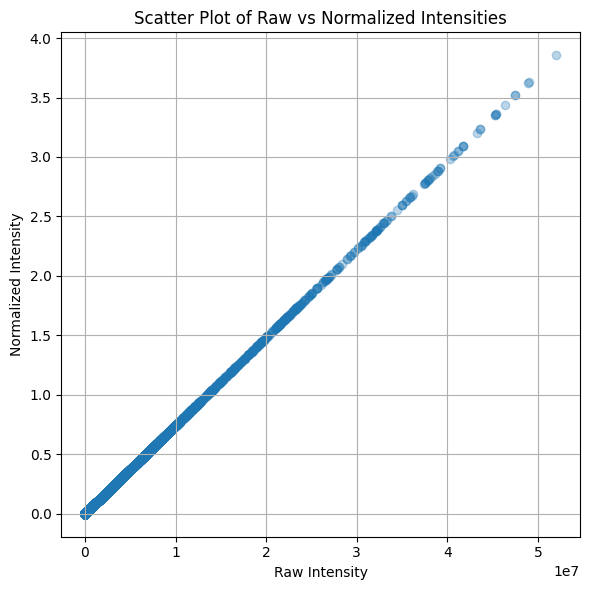

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(tidy_sample_data['Intensity'], tidy_sample_data['Normalized_Intensity'], alpha=0.3)
plt.xlabel("Raw Intensity")
plt.ylabel("Normalized Intensity")
plt.title("Scatter Plot of Raw vs Normalized Intensities")
plt.grid(True)
plt.tight_layout()
plt.show()


The near-perfect straight line means every value was scaled consistently.
In short: the data is successfully normalized while keeping the original structure intact.

# Log‐transform / variance stabilization

We use log transformation to reduce the impact of extreme values and make highly skewed data more balanced

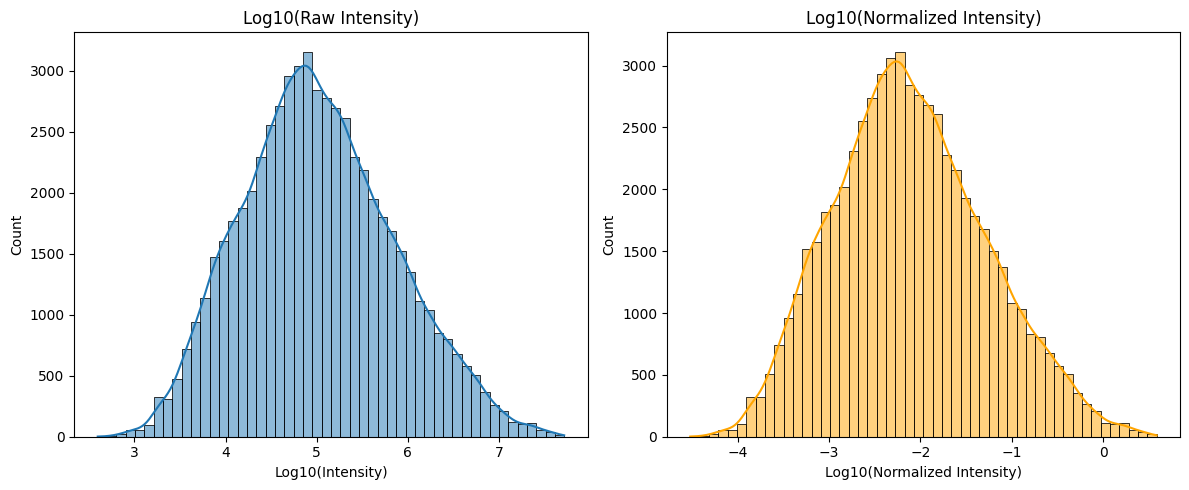

In [13]:


# normalized tidy data
df = pd.read_csv("normalized_tidy_sample_data.csv")

# Add pseudocount to avoid log(0)
pseudocount = 1e-6
df['log_Intensity'] = np.log10(df['Intensity'] + pseudocount)
df['log_Normalized_Intensity'] = np.log10(df['Normalized_Intensity'] + pseudocount)

# Plot histograms to visualize the effect of log transformation
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='log_Intensity', ax=axs[0], bins=50, kde=True)
axs[0].set_title('Log10(Raw Intensity)')
axs[0].set_xlabel("Log10(Intensity)")

sns.histplot(data=df, x='log_Normalized_Intensity', ax=axs[1], bins=50, kde=True, color='orange')
axs[1].set_title('Log10(Normalized Intensity)')
axs[1].set_xlabel("Log10(Normalized Intensity)")

plt.tight_layout()
plt.show()


Normalization adjusted the intensity scale that makes samples more comparable.

Log transformation stabilized variance and made the data more normally distributed.

Both steps together prepare sample data well for multivariate analysis like PCA, clustering, or machine learning.

The distribution is roughly bell-shaped but a bit skewed, meaning some peaks have much higher intensities.

After normalization and log transformation, the values shift to a smaller, more centered range. This shows the data is now on a consistent scale  and  easier to compare across samples.

In [14]:
df

,Peak,tR_best,m/z,ID Names,Sample,Intensity,Peak70_Intensity,Normalized_Intensity,log_Intensity,log_Normalized_Intensity
0,1,1.9055,40,0.14% || 40 ...,s1 S96_44_B1_D1_T1,10596,13493404.3,0.000785,4.025142,-3.104427
1,2,1.9625,44,1.40% || 44 69 119 ...,s1 S96_44_B1_D1_T1,65017,13493404.3,0.004818,4.813027,-2.317004
2,3,1.9745,81,0.19% || 81 96 169 ...,s1 S96_44_B1_D1_T1,25722,13493404.3,0.001906,4.410305,-2.719589
3,4,1.9955,42,12.80% || 42 64 48 40 38 37 66 50 36...,s1 S96_44_B1_D1_T1,3396147,13493404.3,0.251689,6.530986,-0.599133
4,5,2.0415,41,10.30% || 41 39 47 56 77 65 49 60 ...,s1 S96_44_B1_D1_T1,3040149,13493404.3,0.225306,6.482895,-0.647225
...,...,...,...,...,...,...,...,...,...,...
60130,629,23.2630,205,0.17% || 205 220 159 ...,s95 S96_25_B1_D6_T1,16962,13493404.3,0.001257,4.229477,-2.900299
60131,630,23.3140,57,0.21% || 57 99 ...,s95 S96_25_B1_D6_T1,20088,13493404.3,0.001489,4.302937,-2.826893
60132,631,23.3710,191,0.40% || 191 189 85 127 ...,s95 S96_25_B1_D6_T1,74845,13493404.3,0.005547,4.874163,-2.255880
60133,632,23.4120,220,1.02% || 220 115 221 77 105 192 110 ...,s95 S96_25_B1_D6_T1,179081,13493404.3,0.013272,5.253050,-1.877039


# Feature selection

Here i used Anova to do feature selection

In [17]:
# Use log-transformed normalized intensities
log_data_matrix = df.pivot(index="Sample", columns="Peak", values="log_Normalized_Intensity").fillna(0)

# Extract group number from sample name
df['Group'] = df['Sample'].str.extract(r'_D(\d+)_')[0].astype(int)

# Create feature matrix X and group labels y
X = log_data_matrix
y = df.drop_duplicates('Sample').set_index('Sample').loc[X.index]['Group']

# ANOVA feature selection (top 20 peaks)
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X, y)

# Selected peak numbers
selected_peaks = X.columns[selector.get_support()]
print("Top 20 Peaks (by ANOVA):", list(selected_peaks))


Top 20 Peaks (by ANOVA): [3, 7, 78, 79, 190, 211, 247, 545, 546, 550, 552, 553, 554, 555, 601, 602, 605, 610, 612, 633]


As can be seen the result of 20 top peaks from anova also exist in the result achieved by variance threshhold

I use the anova result of feature selesction for finding the outliers

# Identify the outliers

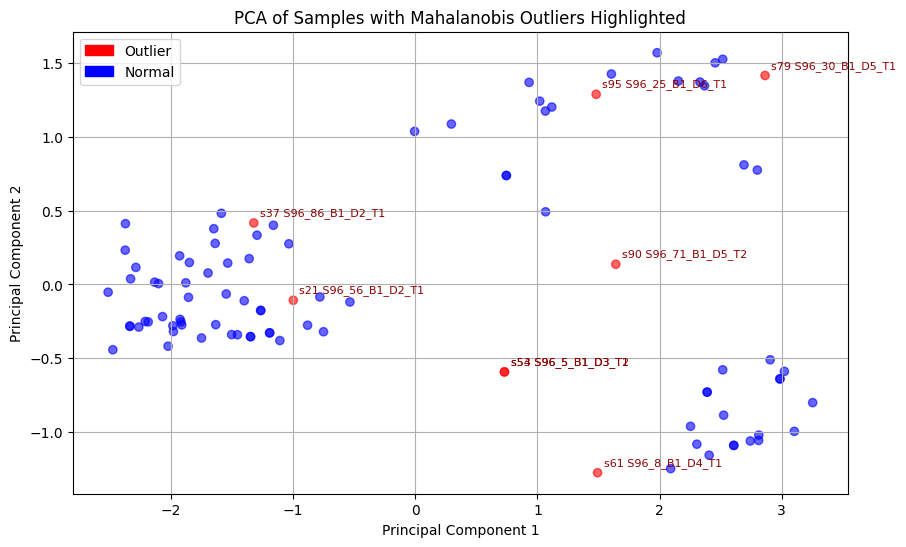

In [18]:


# Rebuild selected_df
selected_df = pd.DataFrame(X_new, index=X.index, columns=selected_peaks)

# Mahalanobis distance
mean_vec = selected_df.mean().values
cov_matrix = np.cov(selected_df.T)
inv_cov_matrix = inv(cov_matrix)
mahal_dists = selected_df.apply(lambda row: mahalanobis(row, mean_vec, inv_cov_matrix), axis=1)
threshold = np.sqrt(stats.chi2.ppf(0.99, df=selected_df.shape[1]))
mahalanobis_outliers = mahal_dists > threshold

# Merge outlier flags with original df
df = df.drop(columns=['is_outlier'], errors='ignore')
df['Sample'] = df['Sample'].astype(str)
sample_flags = pd.Series(mahalanobis_outliers.values, index=selected_df.index, name='is_outlier')
sample_flags.index = sample_flags.index.astype(str)
df = df.merge(sample_flags, left_on='Sample', right_index=True, how='left')

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(selected_df)

# Create PCA DataFrame
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"], index=selected_df.index)



df_selected = df[df['Sample'].isin(selected_df.index.astype(str))].drop_duplicates(subset='Sample')

# Align Sample and is_outlier info with PCA index
df_selected = df_selected.set_index('Sample').loc[selected_df.index.astype(str)]

# Add to pca_df
pca_df['Sample'] = df_selected.index
pca_df['is_outlier'] = df_selected['is_outlier'].values

# Plot
colors = pca_df['is_outlier'].map({True: 'red', False: 'blue'})

plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=colors, alpha=0.6)

# Annotate outliers
for _, row in pca_df[pca_df['is_outlier']].iterrows():
    plt.text(row['PC1'] + 0.05, row['PC2'] + 0.05, row['Sample'], fontsize=8, color='darkred')

plt.title("PCA of Samples with Mahalanobis Outliers Highlighted")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

# Legend
red_patch = mpatches.Patch(color='red', label='Outlier')
blue_patch = mpatches.Patch(color='blue', label='Normal')
plt.legend(handles=[red_patch, blue_patch])

plt.show()


 AS can be seen 8 samples have outliers in terms of peak intensity

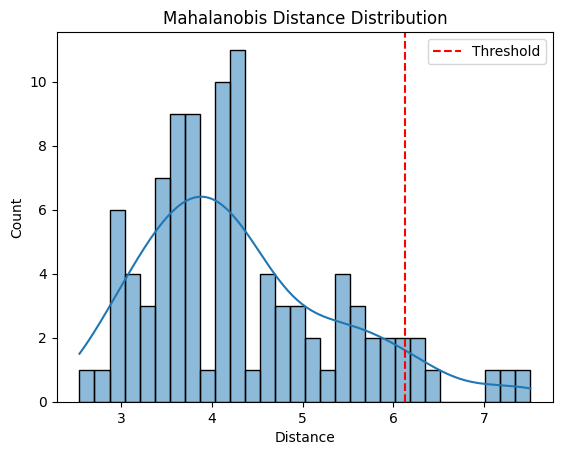

In [19]:
# to see how far outliers really are
sns.histplot(mahal_dists, bins=30, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label="Threshold")
plt.title("Mahalanobis Distance Distribution")
plt.xlabel("Distance")
plt.legend()
plt.show()


beacuse i already used normalization and log transformation i use more sensitive method for getting outliers(Mahalanobis Distance) the red points with theor names were shown in plot

Any samples to the right of the red line are flagged as outliers.

# Handling outliers

Since i need all the varieties, just beacuse of having  some peaks with very high or low value for some samples , i will not remove those sam;ples. instead i do winsorization

In [31]:

from scipy.stats.mstats import winsorize
X_winsor = selected_df.apply(
    lambda col: pd.Series(winsorize(col, limits=[0.01, 0.01]), index=col.index),
    axis=0
)


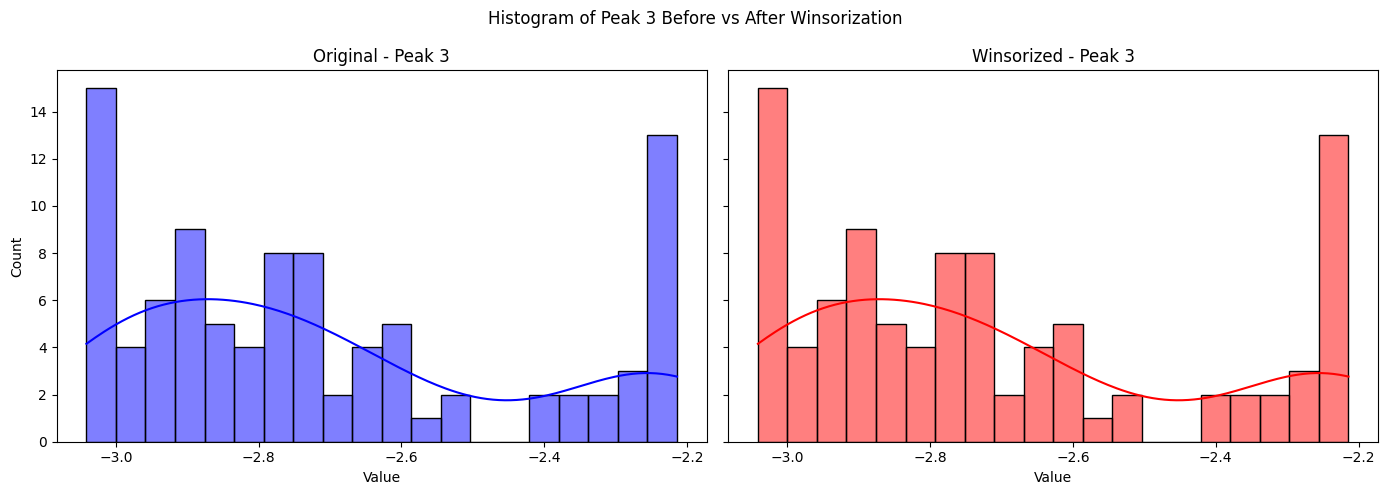

In [32]:
# We aim to observe how Winsorization affects outliers in Peak 3
peak = 3

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# هیستوگرام داده اصلی
sns.histplot(selected_df[peak], bins=20, kde=True, color='blue', ax=axes[0])
axes[0].set_title(f'Original - Peak {peak}')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')

# هیستوگرام داده Winsorized
sns.histplot(X_winsor[peak], bins=20, kde=True, color='red', ax=axes[1])
axes[1].set_title(f'Winsorized - Peak {peak}')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')

plt.suptitle(f'Histogram of Peak {peak} Before vs After Winsorization')
plt.tight_layout()
plt.show()


Since in the histagrams already plotted, dignoising the changing by winsorization , was hard I checked the diffrence in the bellow.

In [33]:
for col in selected_df.columns:
    diff = selected_df[col] - X_winsor[col]
    changed = diff[diff != 0]
    print(f"{col}: {len(changed)} values changed")



3: 0 values changed
7: 0 values changed
78: 0 values changed
79: 0 values changed
190: 0 values changed
211: 0 values changed
247: 0 values changed
545: 0 values changed
546: 0 values changed
550: 0 values changed
552: 0 values changed
553: 0 values changed
554: 0 values changed
555: 0 values changed
601: 0 values changed
602: 0 values changed
605: 0 values changed
610: 0 values changed
612: 0 values changed
633: 0 values changed


Nothing  changed so the winsorizaton does not have any effect. so i do RobustScaler to reduce the ouliers influence

✅ Scaled data saved as 'scaled_sample_data.csv'.


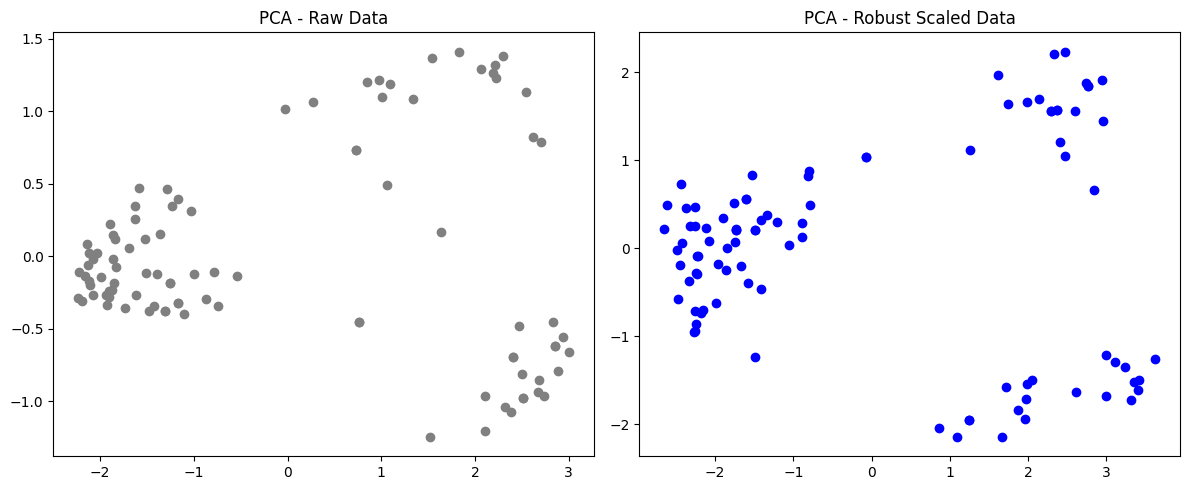

In [36]:

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA


# Load your selected_df if not already loaded
# selected_df = pd.read_csv("your_selected_data.csv", index_col=0)

# 1. Apply Robust Scaling
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(selected_df), 
                        columns=selected_df.columns,
                        index=selected_df.index)

# 2. Save scaled data
X_scaled.to_csv("scaled_sample_data.csv", index=True)
print("✅ Scaled data saved as 'scaled_sample_data.csv'.")

# 3. PCA for visual confirmation
pca = PCA(n_components=2)
pca_raw = pca.fit_transform(selected_df)
pca_scaled = pca.fit_transform(X_scaled)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Raw PCA
axs[0].scatter(pca_raw[:, 0], pca_raw[:, 1], color='gray')
axs[0].set_title("PCA - Raw Data")

# Scaled PCA
axs[1].scatter(pca_scaled[:, 0], pca_scaled[:, 1], color='blue')
axs[1].set_title("PCA - Robust Scaled Data")

plt.tight_layout()
plt.show()


this PCA visualization confirms that Robust Scaling worked well